# **Distance Estimator Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [4]:
# Dataset directory
dataset_path = "../dataset/"

# Retrieve all csv files in the dataset folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Load and merge all datasets
dfs = [pd.read_csv(os.path.join(dataset_path, file)) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)
print("Merge files complete")

Merge files complete


Reading the shape and columns of the dataframe provides information on all the data.

In [5]:
# Print data information
print(f'Number of rows and columns in dataset: {df.shape}')
print()
print(f'Columns in dataset: {df.columns}')

Number of rows and columns in dataset: (42000, 1031)

Columns in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)


## **Data Preparation (Data Cleaning & Data Preprocessing)**

### **Data Cleaning for NaN values**
For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_cleaned.

In [6]:
missingValCount = df.isnull().sum().sum()

if missingValCount > 0:
    df_cleaned = df.dropna()
    print(f'{missingValCount} missing values found and removed from dataset')
else:
    df_cleaned = df.copy()
    print('No missing values found in dataset')

print(f'Shape before cleaning: {df.shape}')
print(f'Shape of cleaned dataset: {df_cleaned.shape}')

No missing values found in dataset
Shape before cleaning: (42000, 1031)
Shape of cleaned dataset: (42000, 1031)


### **Data Visualization and Data Cleaning**

#### **Target Variable: Range**

Boxplot and histogram is used to visualize the distribution of RANGE. Inter-quartile range (IQR) is also used to determine the count of outliers. We will not be removing outliers as these outliers can be meaningful to the prediction of RANGE.

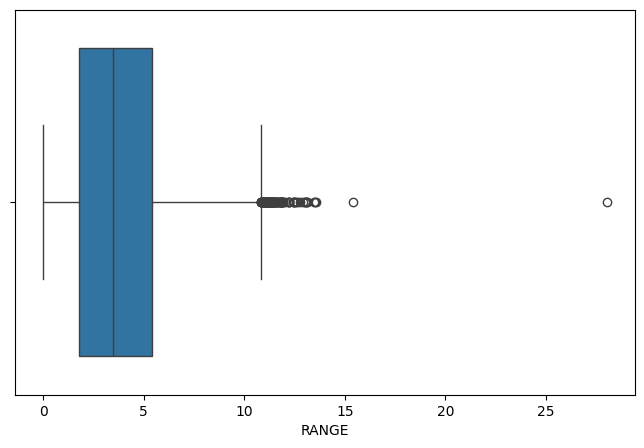

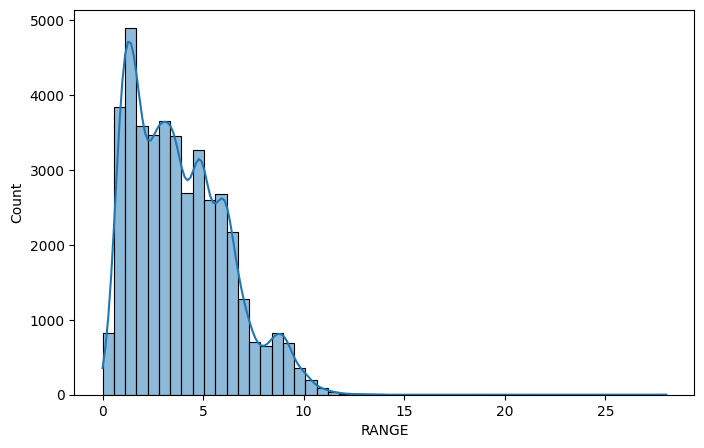

Min: 0.0 Max: 28.02


In [7]:
# Boxplot for RANGE
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["RANGE"])
plt.show()

# Histogram to check distribution
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned["RANGE"], bins=50, kde=True)
plt.show()

# Check min and max values of RANGE
print("Min:", df_cleaned["RANGE"].min(), "Max:", df_cleaned["RANGE"].max())

In [8]:
Q1 = df_cleaned["RANGE"].quantile(0.25)
Q3 = df_cleaned["RANGE"].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df_cleaned[(df_cleaned["RANGE"] < lower_bound) | (df_cleaned["RANGE"] > upper_bound)]
num_outliers = outliers.shape[0]

print("Number of outliers in RANGE:", num_outliers)

Number of outliers in RANGE: 121


#### **Features: FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3**

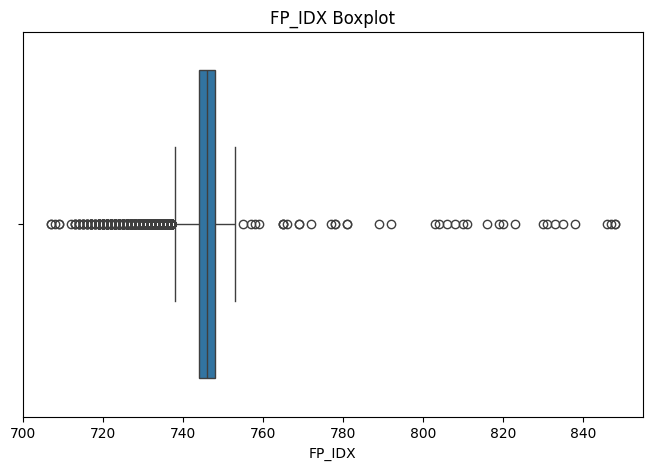

In [9]:
# Plot boxplot for FP_IDX
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["FP_IDX"])
plt.title("FP_IDX Boxplot")
plt.show()

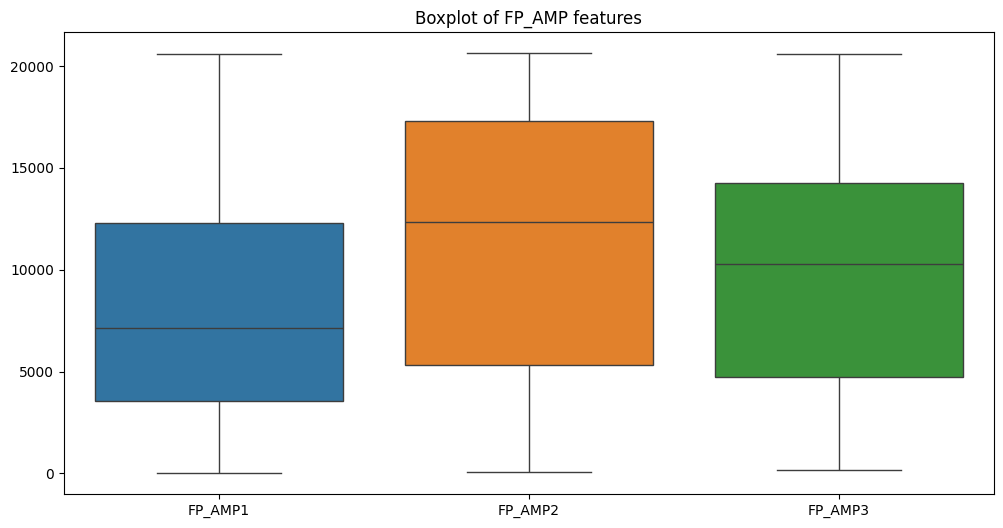

In [10]:
# Plot boxplot for FP_AMP features
# Select features
features = ["FP_AMP1", "FP_AMP2", "FP_AMP3"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of FP_AMP features")
plt.show()

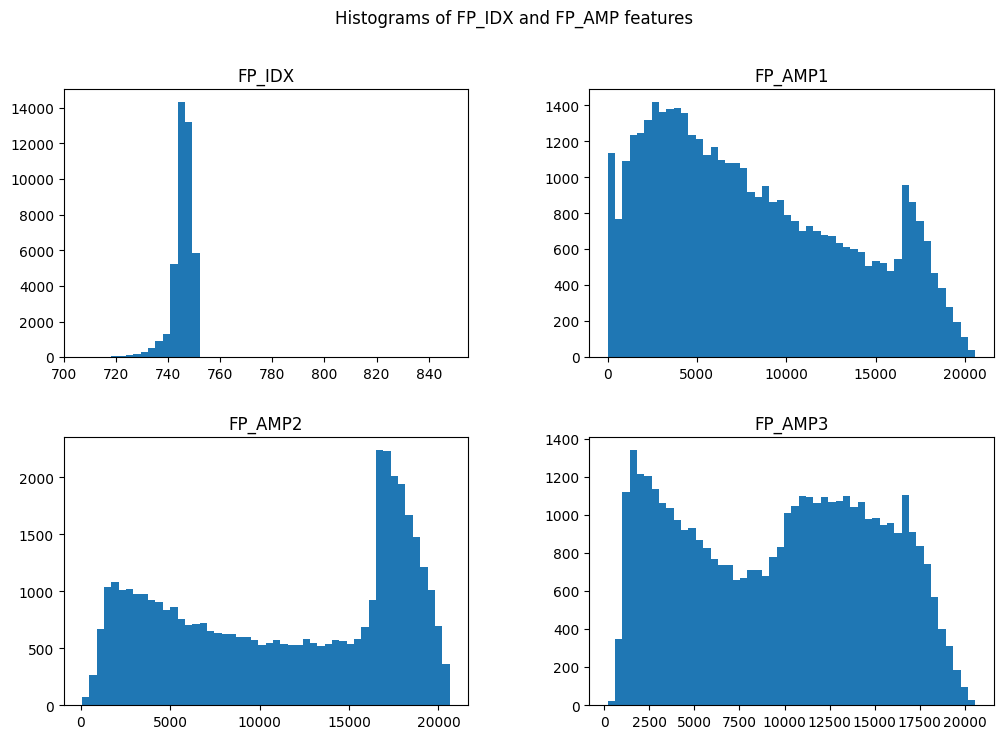

In [11]:
# Plot histogram for FP_IDX and FP_AMP features
# Select features
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

df_cleaned[features].hist(bins=50, figsize=(12,8), grid=False)
plt.suptitle("Histograms of FP_IDX and FP_AMP features")
plt.show()

Here, we only remove **extreme outliers** of FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3 that may highly likely be noise, sensor errors, or unusual environmental interfence.

In [12]:
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

# Determine Q1 and Q2 of features
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df[features] < lower_bound) | (df[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Outlier count per feature:
FP_IDX     622
FP_AMP1      0
FP_AMP2      0
FP_AMP3      0
dtype: int64
Total outliers across all features: 622
Dataset shape after removing outliers: (41378, 1031)


#### **Features: STDEV_NOISE, MAX_NOISE**

For STDEV_NOISE and MAX_NOISE, **extreme outliers** are also removed as these can be likely due to sensor glitches or interference.

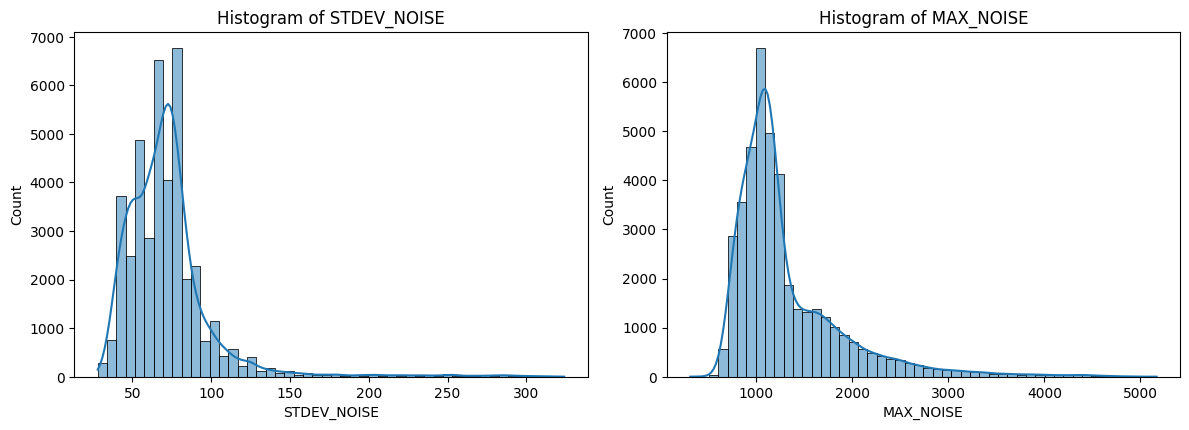

In [13]:
features = ["STDEV_NOISE", "MAX_NOISE"]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_cleaned[feature], bins=50, kde=True)
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

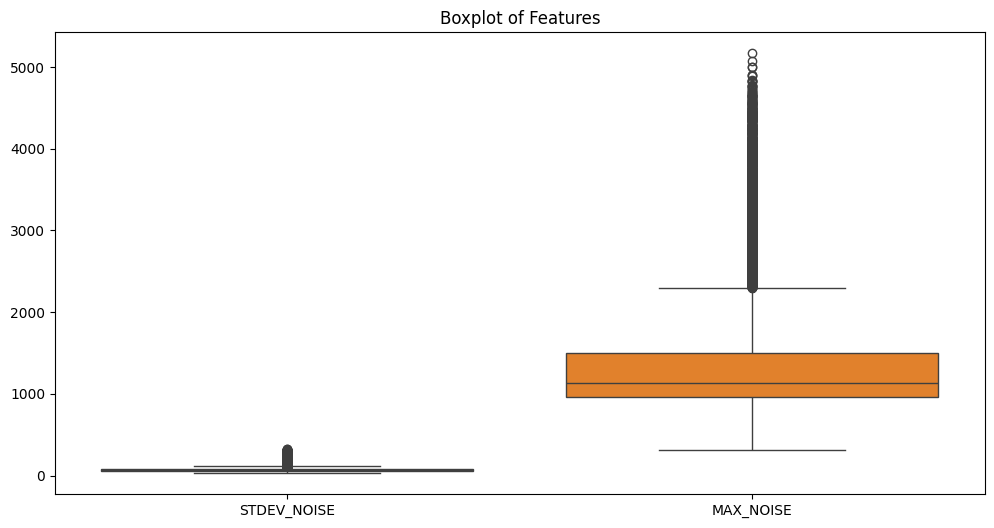

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [15]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print(f'Current dataset shape: {df_cleaned.shape}')
print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Current dataset shape: (41378, 1031)
Outlier count per feature:
STDEV_NOISE    811
MAX_NOISE      871
dtype: int64
Total outliers across all features: 1682
Dataset shape after removing outliers: (40849, 1031)


#### **Feature: CIR_PWR**

For CIR_PWR, we check for impossible values such as **negative and zero values** as Channel Impulse Response power will never be negative.

In [16]:
print(f'Dataset before cleaning: {df_cleaned.shape}')
impossible_cir_pwr_count = (df_cleaned["CIR_PWR"] <= 0).sum()
print(f"Number of CIR_PWR values ≤ 0: {impossible_cir_pwr_count}")

df_cleaned = df_cleaned[df_cleaned["CIR_PWR"] > 0]
print(f"Dataset shape after removing impossible CIR_PWR values: {df_cleaned.shape}")

Dataset before cleaning: (40849, 1031)
Number of CIR_PWR values ≤ 0: 3
Dataset shape after removing impossible CIR_PWR values: (40846, 1031)


#### **Features: RXPACC, FRAME_LEN, PREAM_LEN, CH, BITRATE, PRFR**

For most of these features, the data should be predefined. Hence, we use a histogram to check for multiple unique values. Besides RXPACC which does not have a predefined value, PREAM_LEN has 2 unique values. 

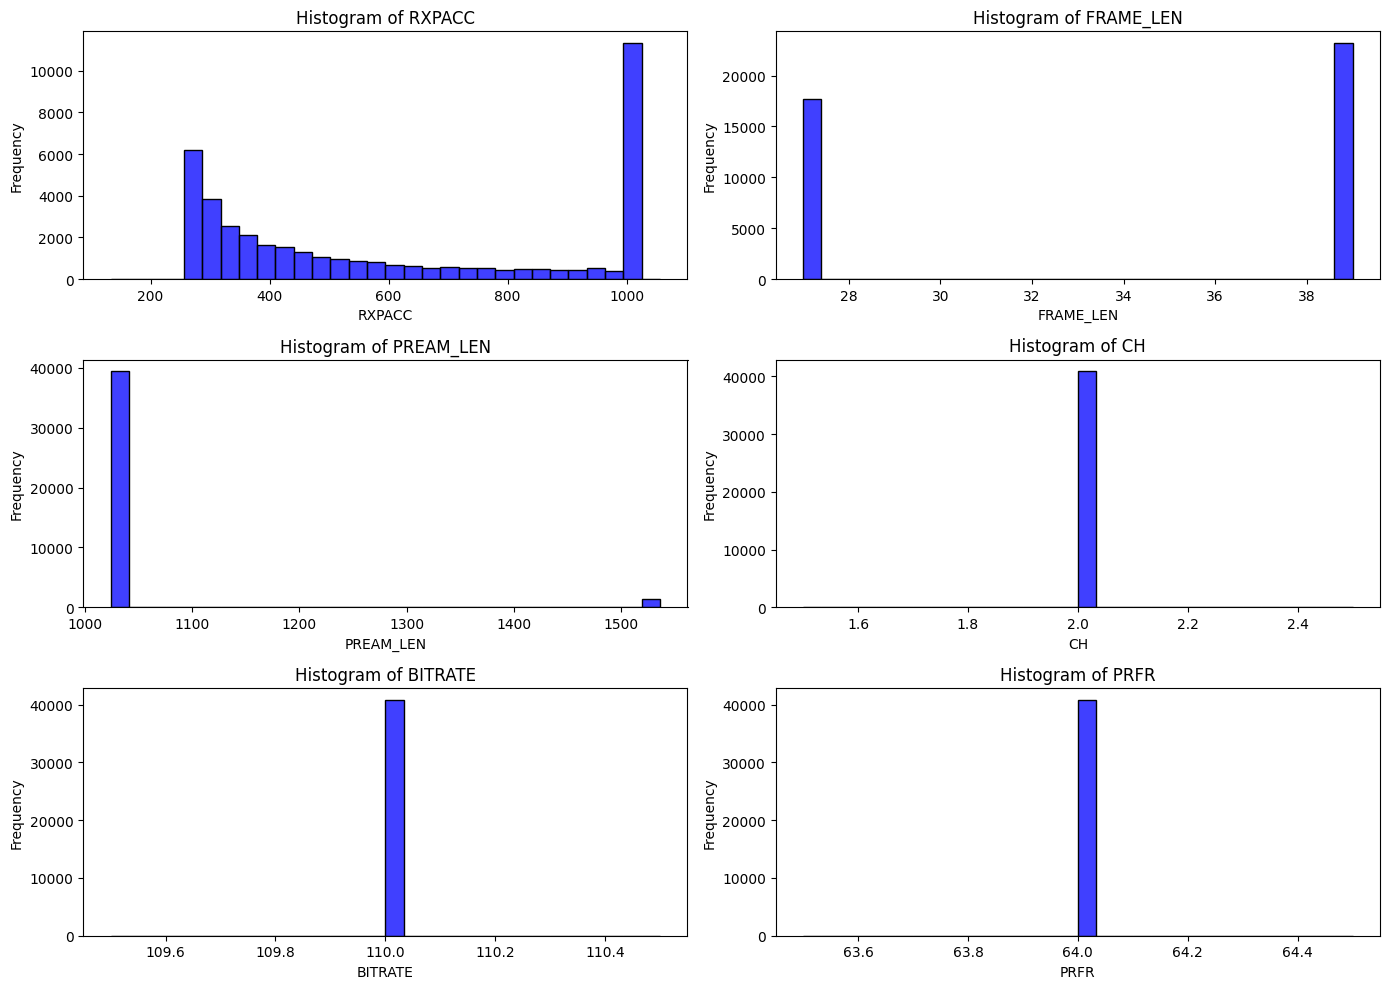

In [17]:
features = ["RXPACC", "FRAME_LEN", "PREAM_LEN", "CH", "BITRATE", "PRFR"]

plt.figure(figsize=(14, 10))

# Loop each feature to plot histogram
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_cleaned[feature], bins=30, color="blue")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

To **check for outliers** on RXPACC and PREAM_LEN, we use boxplots to visualize the distribution of data and IQR to count the extreme outliers.

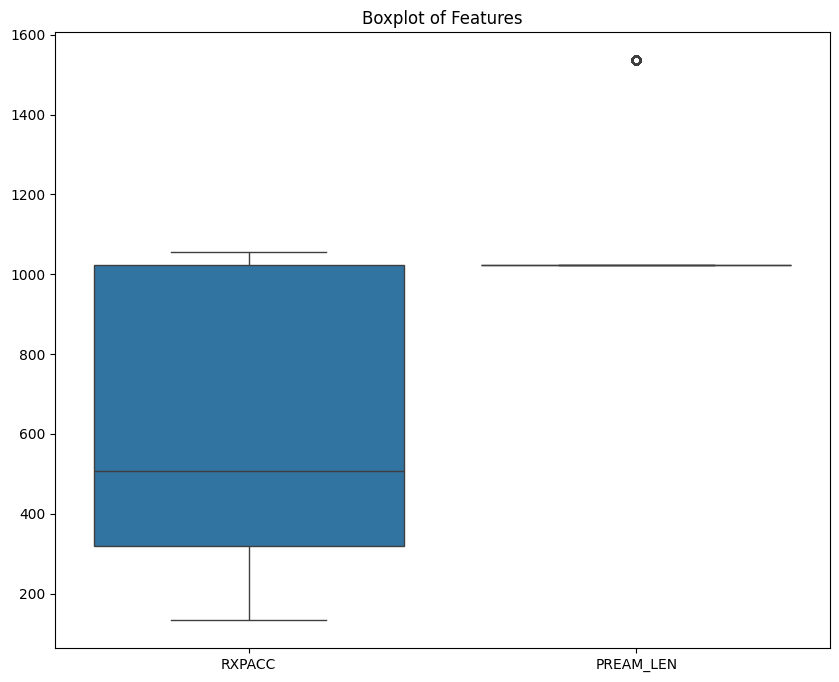

In [18]:
features = ["RXPACC", "PREAM_LEN"]

plt.figure(figsize=(10,8))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [19]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

Outlier count per feature:
RXPACC          0
PREAM_LEN    1478
dtype: int64
Total outliers across all features: 1478


For futher analysis of PREAM_LEN, we used value_counts(). The output are 2 unique values; 1024.0 and 1536.0. Upon research, 1536 is a valid premeable length so we are **not removing this "outlier"**.

In [20]:
df_cleaned["PREAM_LEN"].value_counts()

PREAM_LEN
1024.0    39368
1536.0     1478
Name: count, dtype: int64

### **Data Visualization and Data Preprocessing**

For features CIR0 to CIR1015 (1016 features), we also did data visualization using heatmap to visualize how the the CIR values behave across multiple data points. After which, we **normalized the CIR values** using RXPACC feature to ensure consistency and reduce bias. Finally, we performed **dimensionality reduction using PCA** to reduce the number of CIR features for effective training of our model. This also removes redundancy and transform highly correlated features into a single feature to improve model performance. 

From the heatmap, we can analyze that the CIR values were **scaled very highly before normalization**, possibly due to noises or differences in signal strength.

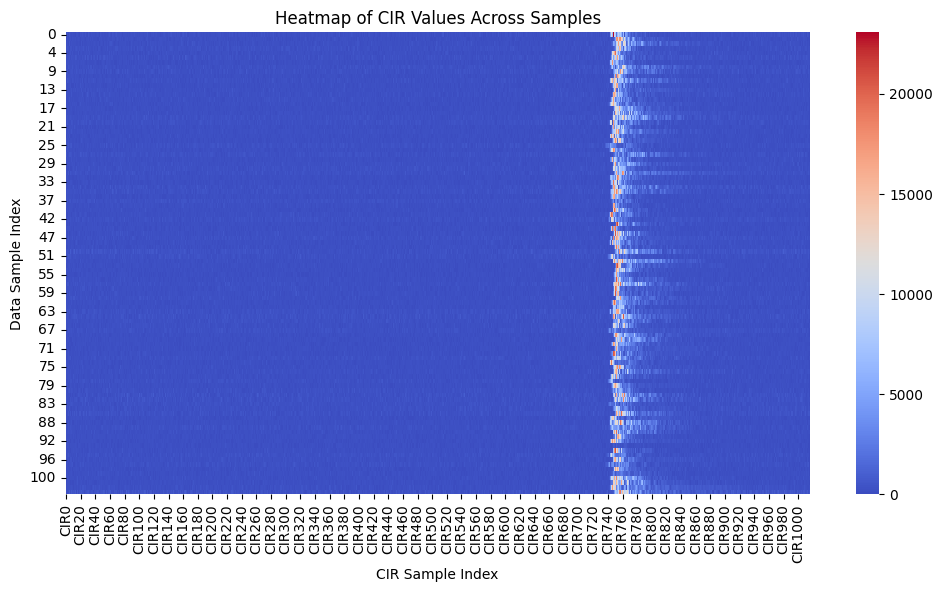

In [21]:
import seaborn as sns

cir_features = [f"CIR{i}" for i in range(1016)]

plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned[cir_features].iloc[:100], cmap="coolwarm")
plt.xlabel("CIR Sample Index")
plt.ylabel("Data Sample Index")
plt.title("Heatmap of CIR Values Across Samples")
plt.show()

#### **Normalization**

After normalization, we can see CIR values that are more comparable with a smaller scale.

In [22]:
# Function to normalize CIR values using RXPACC
def normalize_cir(df):
    df.iloc[:, 15:] = df.iloc[:, 15:].div(df.iloc[:, 9], axis=0)  # Normalize CIR using RXPACC

# Apply normalization to df_cleaned
normalize_cir(df_cleaned)

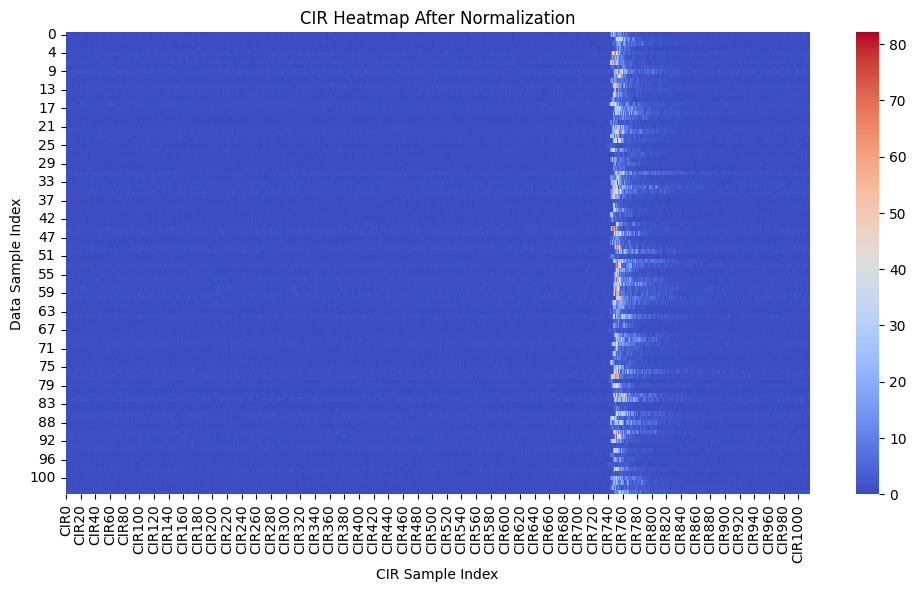

In [23]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.iloc[:100, 15:], cmap="coolwarm")
plt.xlabel("CIR Sample Index")
plt.ylabel("Data Sample Index")
plt.title("CIR Heatmap After Normalization")
plt.show()

#### **Principal Component Analysis (PCA)**

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print(f'Shape before PCA: {df_cleaned.shape}')

# Step 1: Extract CIR Features
cir_features = [f"CIR{i}" for i in range(1016)]
X_cir = df_cleaned[cir_features]  
original_features = X_cir.shape[1]  # Number of features in original dataset

# Step 2: Standardize the Data (PCA requires normalization)
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)

pca = PCA(n_components=0.95)  # Keep 95% variance
X_cir_pca = pca.fit_transform(X_cir_scaled)
reduced_features = X_cir_pca.shape[1]   # Number of features after PCA

# Print PCA results
print(f"New shape of transformed data: {X_cir_pca.shape}")
print(f"Number of features before PCA: {original_features}")
print(f"Number of features after PCA: {reduced_features}")
print(f"Number of features removed: {original_features - reduced_features}")

Shape before PCA: (40846, 1031)
New shape of transformed data: (40846, 842)
Number of features before PCA: 1016
Number of features after PCA: 842
Number of features removed: 174


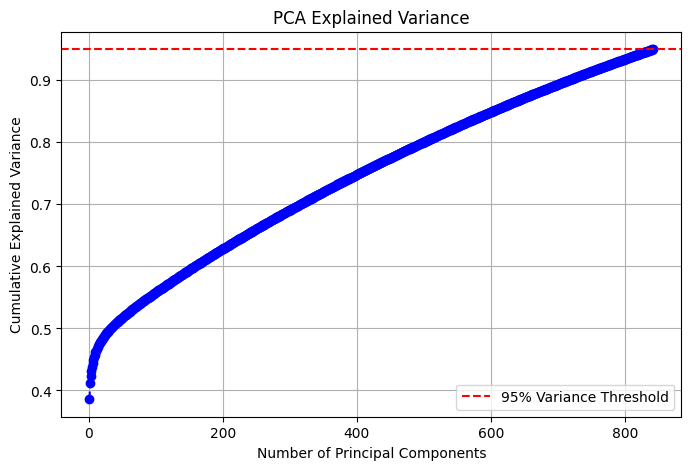

In [25]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()


### **Feature Importance**

To evaluate the feature importance, we explored various visualization graphs such as correlation matrix and mutual information on all features except CIR features. Ultimately, this is to check which features has the **strongest relationship to our target variable**, 'RANGE', such that we can focus on those features and reduce model complexity by removing/ focusing lesser on less important features.

#### **Correlation Matrix**

Correlation matrix detects if the feature has a positive/ negative linear relationship. However, since it can only check for positive/ negative linear relationship, it may not provide an accurate ranking of each feature's importance to our target variable.

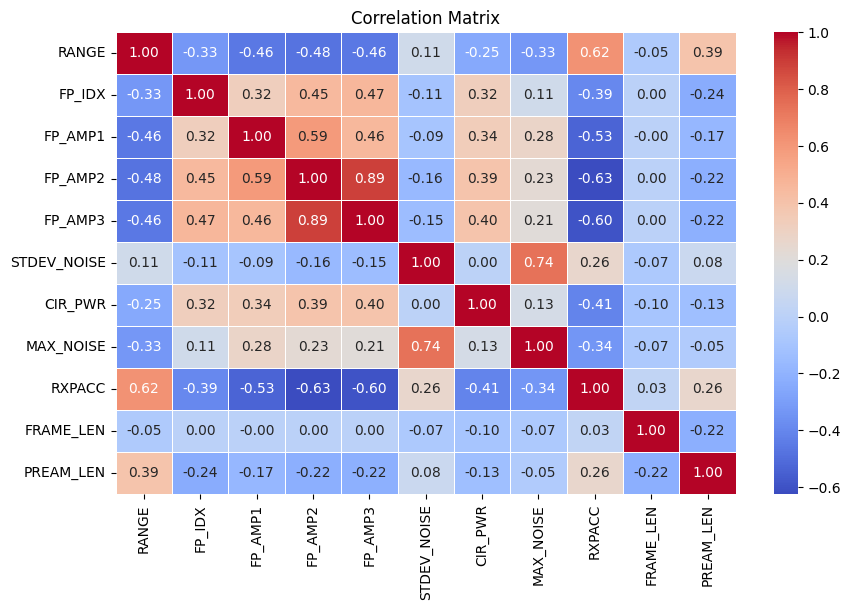

In [26]:
# Shortlisted features to check correlation with each other
features = ['RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Compute the correlation matrix
correlation_matrix = df_cleaned[features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#### **Mutual Information**

Besides the use of correlation matrix, we used mutual information analysis to further check the relationship of our features with our target variable. Mutual information detects both linear and non-linear relationship and provides a better analysis of which feature contributes to the target variable best. 

Mutual Information Scores (in descending order):
RXPACC         0.379131
MAX_NOISE      0.206333
CIR_PWR        0.176656
FP_AMP2        0.149940
FP_AMP1        0.147418
FP_AMP3        0.137294
FP_IDX         0.092127
STDEV_NOISE    0.090866
PREAM_LEN      0.075014
FRAME_LEN      0.011222
dtype: float64


C:\Users\rames\AppData\Local\Temp\ipykernel_19760\2907315880.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")


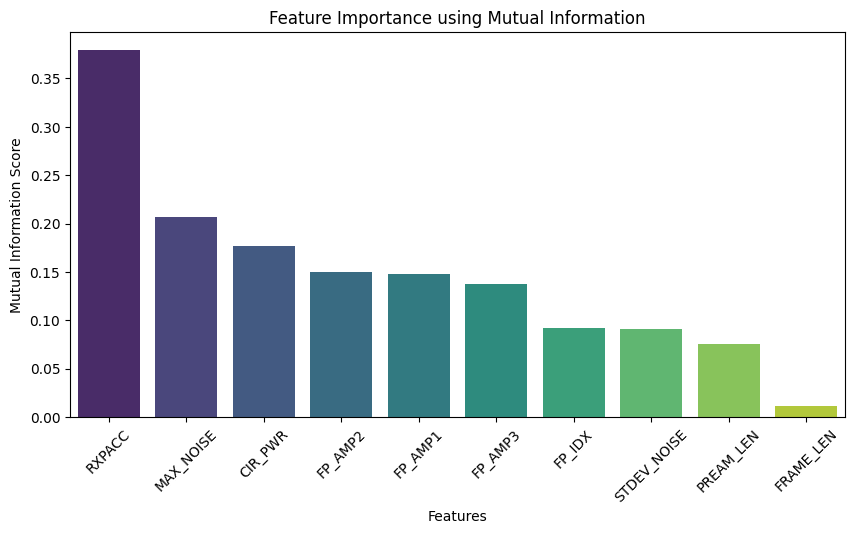

In [27]:
from sklearn.feature_selection import mutual_info_regression

# Features
features = ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Define X as features set
X = df_cleaned[features]

# Define target variable
y = df_cleaned["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

# Plot the scores for better visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

From the correlation matrix and mutual information results, we can infer that **RXPACC has the strongest relationship with RANGE**. Other **notable features are MAX_NOISE and CIR_PWR** that could possibly provide valuable information when training our model. The **lowest importance features are FRAME_LEN and PREAM_LEN** with 0.007965 and 0.075605 MI scores respectively. Though these features are relatively unimportant, we will kepe these features first to check the model's performance with it. 

## **Data Mining**

### **Checking data**

We check the shape and columns to verify the features we are using for data mining

In [28]:
# Checking dataset original shape 
print(f"Dataset shape before removing features: {df_cleaned.shape}")

# Drop original CIR features
df_cleaned = df_cleaned.drop(columns=cir_features)
print(f"Dataset shape after removing CIR features: {df_cleaned.shape}")

# Load PCA features into a drataframe
df_pca = pd.DataFrame(X_cir_pca, columns=[f"PCA{i+1}" for i in range(reduced_features)])
print(f"Shape of PCA dataset: {df_pca.shape}")

# Add PCA features to the dataframe
df_cleaned = pd.concat([df_cleaned.reset_index(drop=True), df_pca.reset_index(drop=True)], axis=1)

# Print the updated dataframe shape
print()
print(f"Updated dataframe shape: {df_cleaned.shape}")
print(f"Updated dataframe columns: {df_cleaned.columns}")
print(f"NaN values in updated dataframe: {df_cleaned.isnull().sum().sum()}")

Dataset shape before removing features: (40846, 1031)
Dataset shape after removing CIR features: (40846, 15)
Shape of PCA dataset: (40846, 842)

Updated dataframe shape: (40846, 857)
Updated dataframe columns: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'PCA833', 'PCA834', 'PCA835', 'PCA836', 'PCA837', 'PCA838', 'PCA839',
       'PCA840', 'PCA841', 'PCA842'],
      dtype='object', length=857)
NaN values in updated dataframe: 0


### **Data Splitting**

#### **80-20 split**

give ur reasoning here. 1-2 sentence can alr

In [29]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_cleaned.drop(columns=["RANGE"])
y = df_cleaned["RANGE"]

# Perform 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes to verify
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training feature set shape: (32676, 856)
Testing feature set shape: (8170, 856)
Training labels shape: (32676,)
Testing labels shape: (8170,)


#### **Check for NaN values**

Last check for NaN values before training the model. This is done as we faced NaN values when concatinating df_pca into df_cleaned.

In [30]:
# Check if there are any NaN values in X_train or y_train
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in y_train:", y_train.isnull().sum())

NaN values in X_train: 0
NaN values in y_train: 0


### **Machine Learning**

Overview of all ur machine learning algos

#### **Linear Regression [change if wrong]**

Linear Regression is simple, interpretable, and fast. It provides a good baseline to compare more complex models against. 

Epoch 1/100 - Train Loss (MSE): 2.4295 - Val Loss (MSE): 2.6465
Epoch 2/100 - Train Loss (MSE): 2.3304 - Val Loss (MSE): 2.5492
Epoch 3/100 - Train Loss (MSE): 2.3220 - Val Loss (MSE): 2.5466
Epoch 4/100 - Train Loss (MSE): 2.3186 - Val Loss (MSE): 2.5456
Epoch 5/100 - Train Loss (MSE): 2.3164 - Val Loss (MSE): 2.5451
Epoch 6/100 - Train Loss (MSE): 2.3147 - Val Loss (MSE): 2.5441
Epoch 7/100 - Train Loss (MSE): 2.3133 - Val Loss (MSE): 2.5435
Epoch 8/100 - Train Loss (MSE): 2.3122 - Val Loss (MSE): 2.5426
Epoch 9/100 - Train Loss (MSE): 2.3112 - Val Loss (MSE): 2.5422
Epoch 10/100 - Train Loss (MSE): 2.3103 - Val Loss (MSE): 2.5415
Epoch 11/100 - Train Loss (MSE): 2.3095 - Val Loss (MSE): 2.5412
Epoch 12/100 - Train Loss (MSE): 2.3089 - Val Loss (MSE): 2.5406
Epoch 13/100 - Train Loss (MSE): 2.3083 - Val Loss (MSE): 2.5404
Epoch 14/100 - Train Loss (MSE): 2.3078 - Val Loss (MSE): 2.5399
Epoch 15/100 - Train Loss (MSE): 2.3073 - Val Loss (MSE): 2.5398
Epoch 16/100 - Train Loss (MSE): 2

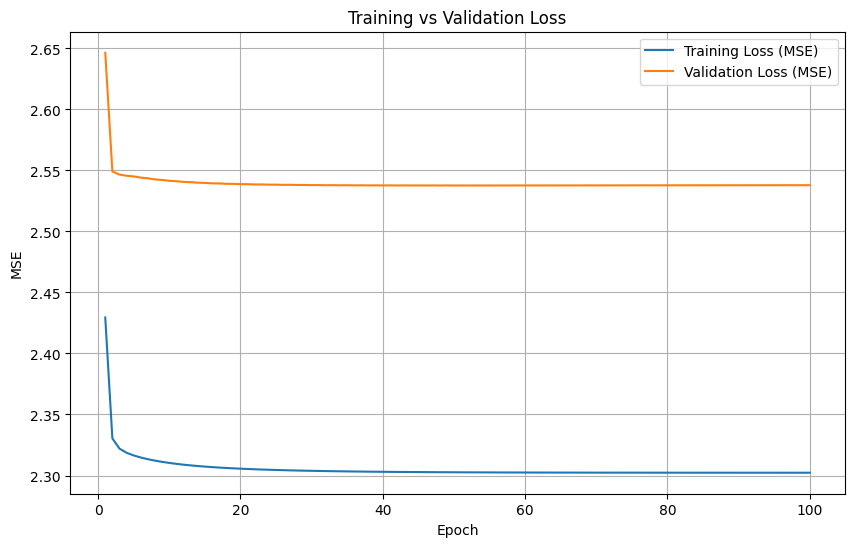


✅ Training completed.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import joblib

# ➡️ Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ➡️ Split into training and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

# ➡️ Initialize SGDRegressor (or any model)
sgd_reg = SGDRegressor(
    max_iter=1,
    learning_rate='constant',
    eta0=0.0001,
    penalty='l2',
    random_state=42,
    warm_start=True,
    early_stopping=False,
    tol=None
)

# ➡️ Training loop
n_epochs = 100
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    sgd_reg.fit(X_train_final, y_train_final)

    # Evaluate losses
    y_train_pred = sgd_reg.predict(X_train_final)
    y_val_pred = sgd_reg.predict(X_val)

    train_loss = mean_squared_error(y_train_final, y_train_pred)
    val_loss = mean_squared_error(y_val, y_val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Progress log
    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss (MSE): {train_loss:.4f} - Val Loss (MSE): {val_loss:.4f}")


print("\n✅ Training completed.")


In [138]:
# ➡️ Save the trained model
model_save_path = 'final_trained_linear_regrssion_model.joblib'
joblib.dump(sgd_reg, model_save_path)

print(f"\n✅ Model saved to {model_save_path}")


✅ Model saved to final_trained_linear_regrssion_model.joblib


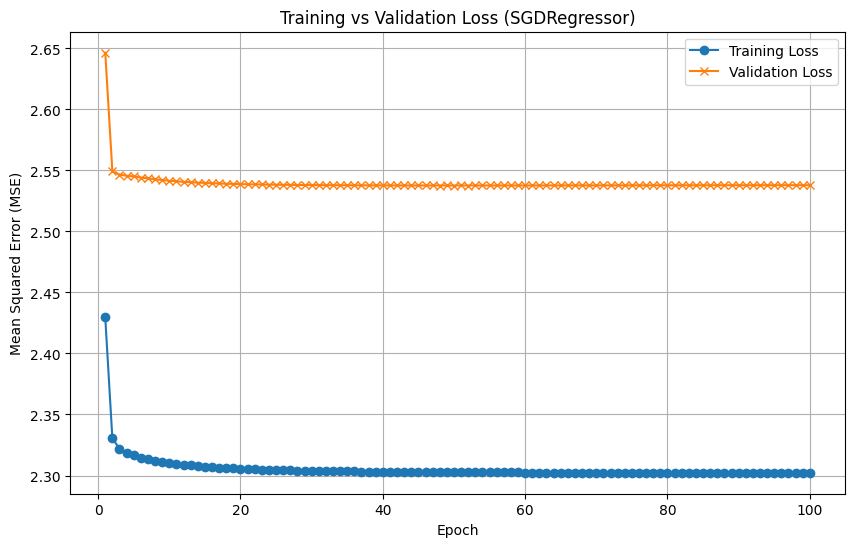

In [139]:
#  Plot Training vs Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, n_epochs + 1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training vs Validation Loss (SGDRegressor)')
plt.legend()
plt.grid(True)
plt.show()

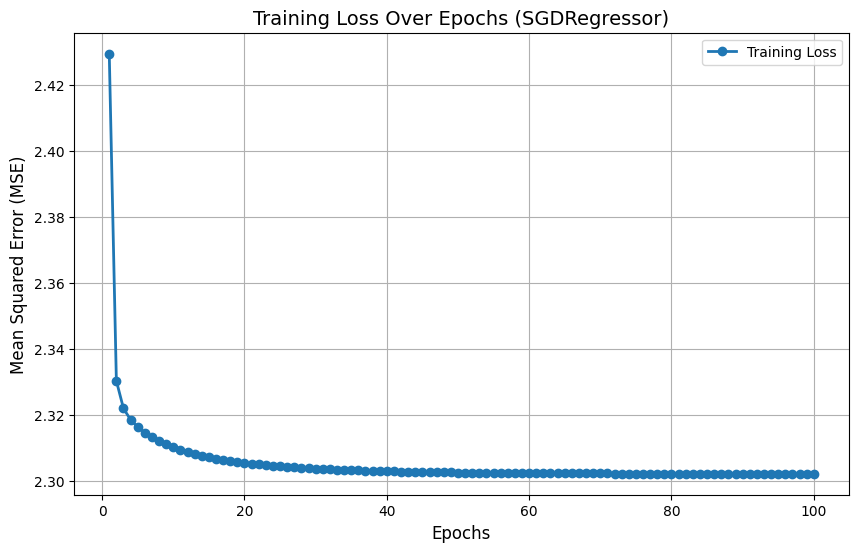

In [140]:

plt.figure(figsize=(10, 6))  # Increase figure size for clarity
plt.plot(range(1, n_epochs + 1), train_losses, marker='o', linestyle='-', linewidth=2, label='Training Loss')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training Loss Over Epochs (SGDRegressor)', fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


In [141]:
# Evaluate Final Model on the Test Set
y_pred_test = sgd_reg.predict(X_test_scaled)

# Calculate performance metrics on test set
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

# Print results
print("\nTest Set Performance After Training (With Scaled Data):")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")



Test Set Performance After Training (With Scaled Data):
Mean Absolute Error (MAE): 1.2307
Mean Squared Error (MSE): 2.5250
Root Mean Squared Error (RMSE): 1.5890
R-squared (R2): 0.5354


In [142]:
#  Display first 10 Actual vs Predicted values
import pandas as pd
comparison_df = pd.DataFrame({
    'Actual RANGE': y_test.values[:10],
    'Predicted RANGE': y_pred_test[:10]
})

print("\nFirst 10 Actual vs. Predicted RANGE values:")
print(comparison_df.to_string(index=False))


First 10 Actual vs. Predicted RANGE values:
 Actual RANGE  Predicted RANGE
         5.74         4.389655
         1.37         2.551719
         5.15         5.138895
         2.09         2.839772
         3.46         4.333259
         3.59         3.365312
         1.92         0.764878
         3.83         4.989673
         5.68         5.028991
         3.61         4.999221


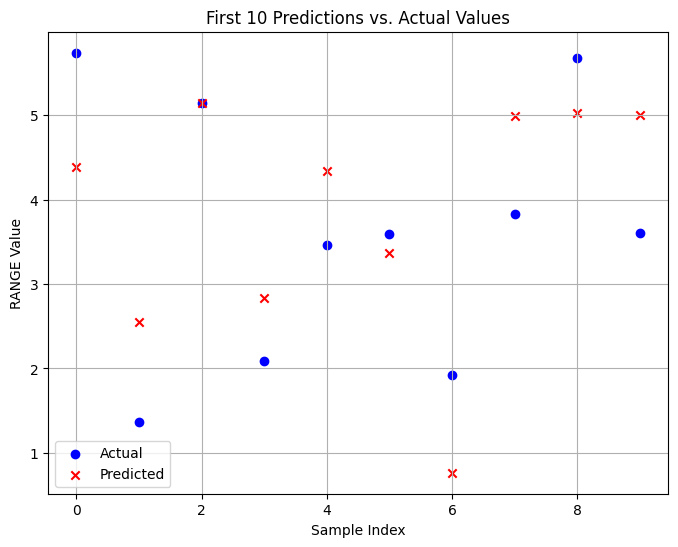

In [143]:
import pandas as pd

# Create a DataFrame to compare predicted and actual values
comparison_df = pd.DataFrame({
    'Actual RANGE': y_test.values[:10],
    'Predicted RANGE': y_pred_test[:10]
})

# ➡️ Plot first 10 predictions
plt.figure(figsize=(8, 6))
plt.scatter(range(10), y_test.values[:10], label="Actual", marker='o', color='blue')
plt.scatter(range(10), y_pred_test[:10], label="Predicted", marker='x', color='red')
plt.xlabel("Sample Index")
plt.ylabel("RANGE Value")
plt.title("First 10 Predictions vs. Actual Values")
plt.legend()
plt.grid(True)
plt.show()


In [144]:
import joblib

# Load the model you saved earlier
best_model = joblib.load('final_trained_linear_regrssion_model.joblib')

# Evaluate on validation or test set (preferably test)
y_pred_test = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("Model loaded from disk:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Model loaded from disk:
Mean Absolute Error (MAE): 1.2307
Mean Squared Error (MSE): 2.5250
Root Mean Squared Error (RMSE): 1.5890
R-squared (R2): 0.5354


XGBoost Regresso

In [145]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# ---------------------------------------------------
# 2. Scaling Features
# ---------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------
# 3. Create XGBoost DMatrix for better performance (Optional but recommended)
# ---------------------------------------------------
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# ---------------------------------------------------
# 4. Set XGBoost Parameters
# ---------------------------------------------------
params = {
    'objective': 'reg:squarederror',   # Regression task
    'eval_metric': 'rmse',             # Evaluation metric
    'eta': 0.1,                        # Learning rate
    'max_depth': 6,                    # Depth of trees
    'subsample': 0.8,                  # Subsample rows
    'colsample_bytree': 0.8,           # Subsample columns
    'seed': 42
}

# ---------------------------------------------------
# 5. Watchlist for Training & Validation Loss Tracking
# ---------------------------------------------------
evals_result = {}  # To store log of training

# ---------------------------------------------------
# 6. Train XGBoost Model with Epochs (n_estimators)
# ---------------------------------------------------
num_epochs = 100

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_epochs,         # Number of epochs
    evals=[(dtrain, 'train'), (dtest, 'validation')],
    evals_result=evals_result,
    verbose_eval=True
)

[0]	train-rmse:2.21607	validation-rmse:2.19948
[1]	train-rmse:2.09772	validation-rmse:2.08964
[2]	train-rmse:1.99701	validation-rmse:1.99500
[3]	train-rmse:1.90291	validation-rmse:1.90609
[4]	train-rmse:1.82764	validation-rmse:1.83658
[5]	train-rmse:1.76405	validation-rmse:1.77804
[6]	train-rmse:1.70032	validation-rmse:1.71984
[7]	train-rmse:1.64405	validation-rmse:1.66827
[8]	train-rmse:1.59175	validation-rmse:1.62167
[9]	train-rmse:1.55220	validation-rmse:1.58668
[10]	train-rmse:1.51284	validation-rmse:1.55213
[11]	train-rmse:1.48113	validation-rmse:1.52529
[12]	train-rmse:1.45058	validation-rmse:1.49894
[13]	train-rmse:1.43020	validation-rmse:1.48244
[14]	train-rmse:1.41239	validation-rmse:1.46791
[15]	train-rmse:1.39130	validation-rmse:1.45057
[16]	train-rmse:1.37093	validation-rmse:1.43430
[17]	train-rmse:1.35421	validation-rmse:1.42110
[18]	train-rmse:1.33674	validation-rmse:1.40822
[19]	train-rmse:1.31822	validation-rmse:1.39444
[20]	train-rmse:1.30605	validation-rmse:1.38635
[2

In [146]:
# Save the model to a file
model_save_path = 'final_xgb_model.json'

# Use XGBoost's save_model method
xgb_model.save_model(model_save_path)

print(f"\n✅ Model saved to {model_save_path}")



✅ Model saved to final_xgb_model.json


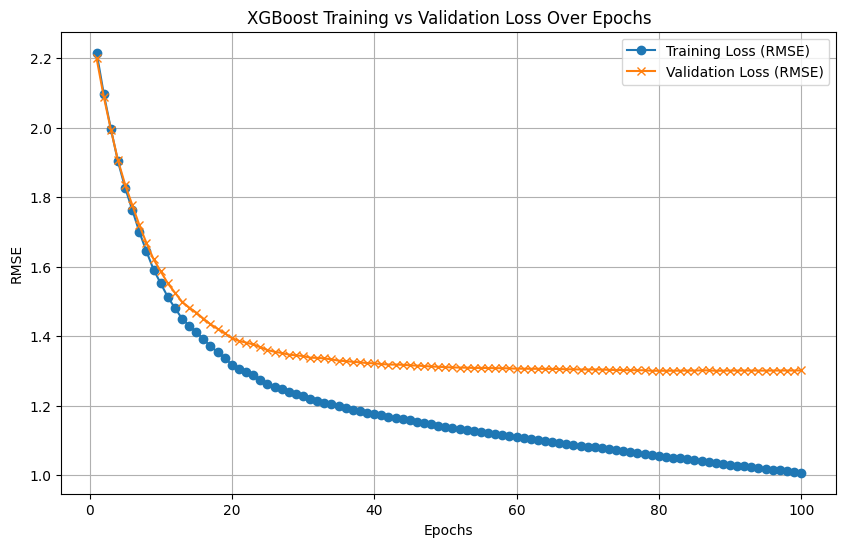

In [38]:
# ---------------------------------------------------
# 7. Plot Training vs Validation Loss over Epochs
# ---------------------------------------------------
epochs_range = range(1, num_epochs + 1)
train_loss = evals_result['train']['rmse']
val_loss = evals_result['validation']['rmse']

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss, label='Training Loss (RMSE)', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss (RMSE)', marker='x')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('XGBoost Training vs Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [147]:
y_pred_test = xgb_model.predict(dtest)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Set Performance After Training (With XGBoost):")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")


Test Set Performance After Training (With XGBoost):
Mean Absolute Error (MAE): 0.9871
Mean Squared Error (MSE): 1.6937
Root Mean Squared Error (RMSE): 1.3014
R-squared (R2): 0.6884


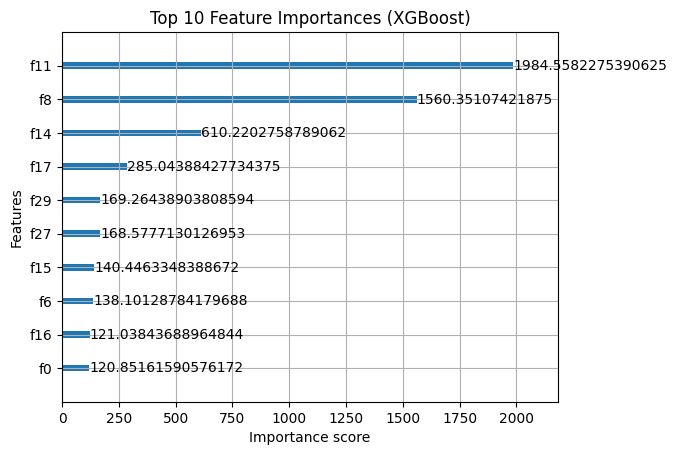

In [40]:
# ---------------------------------------------------
# 9. Feature Importance Plot
# ---------------------------------------------------
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

In [41]:
# ---------------------------------------------------
# 10. Display First 10 Predictions vs Actual
# ---------------------------------------------------
comparison_df = pd.DataFrame({
    'Actual RANGE': y_test.values[:10],
    'Predicted RANGE': y_pred_test[:10]
})

print("\nFirst 10 Actual vs. Predicted RANGE values:")
print(comparison_df.to_string(index=False))




First 10 Actual vs. Predicted RANGE values:
 Actual RANGE  Predicted RANGE
         5.74         3.743302
         1.37         2.635436
         5.15         5.039364
         2.09         2.704896
         3.46         3.667560
         3.59         2.664741
         1.92         0.817170
         3.83         4.887171
         5.68         4.624616
         3.61         4.490211


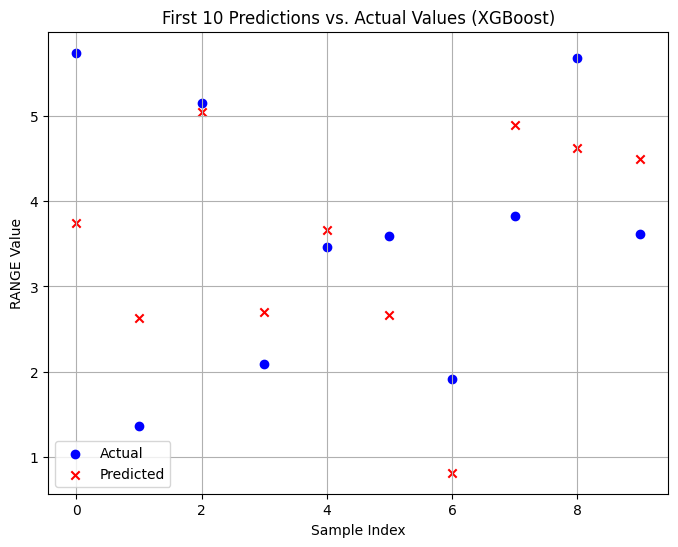

In [42]:
# Plot comparison
plt.figure(figsize=(8, 6))
plt.scatter(range(10), y_test.values[:10], label="Actual", marker='o', color='blue')
plt.scatter(range(10), y_pred_test[:10], label="Predicted", marker='x', color='red')
plt.xlabel("Sample Index")
plt.ylabel("RANGE Value")
plt.title("First 10 Predictions vs. Actual Values (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

In [148]:
import xgboost as xgb

# Load the saved model
loaded_model = xgb.Booster()
loaded_model.load_model('final_xgb_model.json')

# Use it to predict
dtest = xgb.DMatrix(X_test_scaled)
y_pred = loaded_model.predict(dtest)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n✅ Test Set Performance (Loaded XGBoost Model):")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")



✅ Test Set Performance (Loaded XGBoost Model):
MAE: 0.9871
MSE: 1.6937
RMSE: 1.3014
R2: 0.6884
